# Notebook 1: Supervised Neighbourhood Classification
## Random Forest & Gradient Boosting vs Rule-Based Baseline

**Purpose:** Train supervised ML classifiers on 1,527 neighbourhood-level features to predict  
crime intensity class (High / Moderate / Lower Crime), then compare against the existing  
rule-based classification system.

**Key Contribution:**  
- Demonstrates ML can learn meaningful crime patterns from neighbourhood data  
- Feature importance analysis reveals which variables most drive classification  
- Direct comparison validates (or challenges) the rule-based approach  
- Justifies Rudin (2019): if both approaches agree, the interpretable one is preferable

**ML Methods:** Random Forest Classifier, Gradient Boosting Classifier  
**Evaluation:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Feature Importance

## 1. Setup and Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, f1_score
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COLORS = ['#3ecfcf', '#1b9e9e', '#0d1b2a', '#f4a261', '#e76f51']

print("All imports loaded successfully.")

All imports loaded successfully.


## 2. Load and Prepare Data

In [ ]:
# ── Load neighbourhood and area-level data ──
from settings import PROCESSED_DIR

neigh = pd.read_parquet(PROCESSED_DIR / "neighbourhood_classified.parquet")
areas = pd.read_parquet(PROCESSED_DIR / "area_classified.parquet")

print(f"Neighbourhoods: {len(neigh)} rows, {neigh.shape[1]} columns")
print(f"Areas:          {len(areas)} rows, {areas.shape[1]} columns")
print(f"\nNeighbourhood columns: {list(neigh.columns)}")
print(f"\nTarget variable (neigh_intensity) distribution:")
print(neigh['neigh_intensity'].value_counts())

Neighbourhoods: 1527 rows, 20 columns
Areas:          15 rows, 21 columns

Neighbourhood columns: ['la_code', 'neighbourhood_id', 'total_crimes', 'violent_count', 'property_count', 'months_present', 'avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope', 'top_crime_category', 'la_name', 'neighbourhood_name', 'centroid_lat', 'centroid_lon', 'crime_rank', 'total_neighs', 'rank_pct', 'neigh_intensity', 'neigh_trend']

Target variable (neigh_intensity) distribution:
neigh_intensity
High Crime        521
Lower Crime       506
Moderate Crime    500
Name: count, dtype: int64


## 3. Feature Engineering

We enrich each neighbourhood with its parent Local Authority's characteristics.  
This gives the model both local (neighbourhood) and contextual (area-level) features,  
which mirrors how crime patterns work in practice — a neighbourhood's risk depends  
on both its own characteristics and the broader area context.

In [39]:
# ── Select LA-level features to join ──
la_features = areas[[
    'la_code', 'avg_monthly_crimes', 'avg_violent_share', 'avg_property_share',
    'crime_variability', 'avg_tavg', 'avg_monthly_prcp', 'cold_month_count',
    'prcp_variability', 'crime_trend_slope'
]].rename(columns={
    'avg_monthly_crimes': 'la_avg_monthly_crimes',
    'avg_violent_share': 'la_avg_violent_share',
    'avg_property_share': 'la_avg_property_share',
    'crime_variability': 'la_crime_variability',
    'avg_tavg': 'la_avg_tavg',
    'avg_monthly_prcp': 'la_avg_monthly_prcp',
    'cold_month_count': 'la_cold_month_count',
    'prcp_variability': 'la_prcp_variability',
    'crime_trend_slope': 'la_crime_trend_slope'
})

# ── Merge neighbourhood + LA features ──
df = neigh.merge(la_features, on='la_code', how='left')
print(f"Merged dataset: {len(df)} rows, {df.shape[1]} columns")

# ── Define feature columns and target ──
FEATURE_COLS = [
    # Neighbourhood-level features
    'avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope',
    # LA-level context features
    'la_avg_monthly_crimes', 'la_avg_violent_share', 'la_avg_property_share',
    'la_crime_variability', 'la_avg_tavg', 'la_avg_monthly_prcp',
    'la_cold_month_count', 'la_prcp_variability', 'la_crime_trend_slope'
]

TARGET = 'neigh_intensity'

# ── Handle missing values ──
print(f"\nMissing values in features:")
print(df[FEATURE_COLS].isnull().sum()[df[FEATURE_COLS].isnull().sum() > 0])

# Fill NaN trend_slope with 0 (stable — no trend data means insufficient months)
df['trend_slope'] = df['trend_slope'].fillna(0)

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Merged dataset: 1527 rows, 29 columns

Missing values in features:
Series([], dtype: int64)

Feature matrix shape: (1527, 13)
Target distribution:
neigh_intensity
High Crime        521
Lower Crime       506
Moderate Crime    500
Name: count, dtype: int64


## 4. Exploratory Analysis of Features

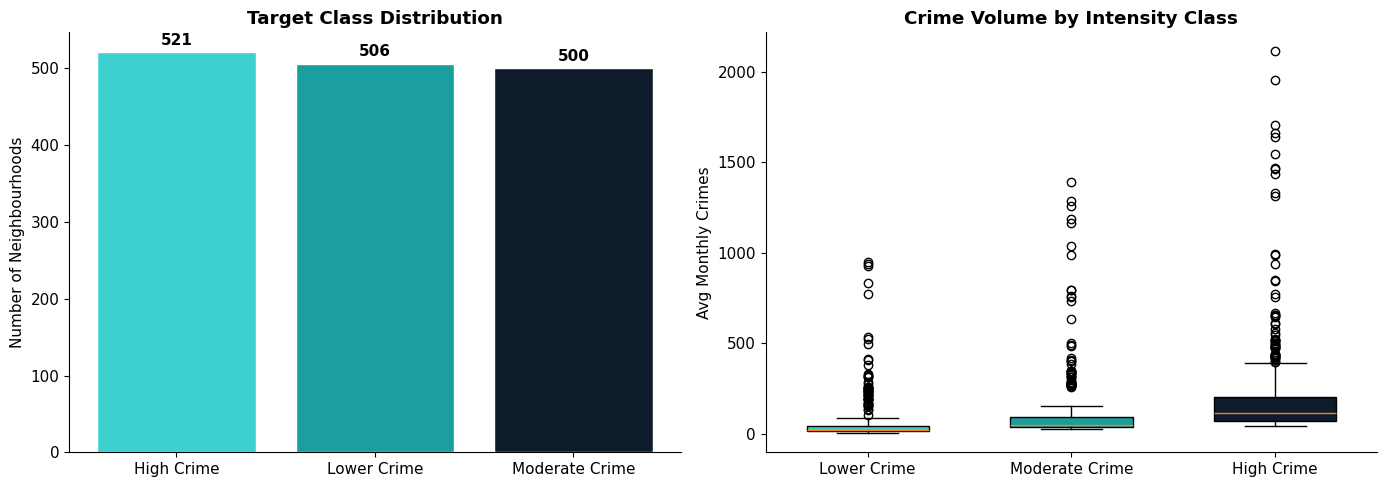

Saved: nb1_class_distribution.png


In [40]:
# ── Class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = y.value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=COLORS[:3], edgecolor='white')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Neighbourhoods')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

for i, cls in enumerate(['Lower Crime', 'Moderate Crime', 'High Crime']):
    subset = df[df[TARGET] == cls]['avg_monthly_crimes']
    bp = axes[1].boxplot(subset, positions=[i], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(COLORS[i])
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Lower Crime', 'Moderate Crime', 'High Crime'])
axes[1].set_title('Crime Volume by Intensity Class', fontweight='bold')
axes[1].set_ylabel('Avg Monthly Crimes')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_class_distribution.png")

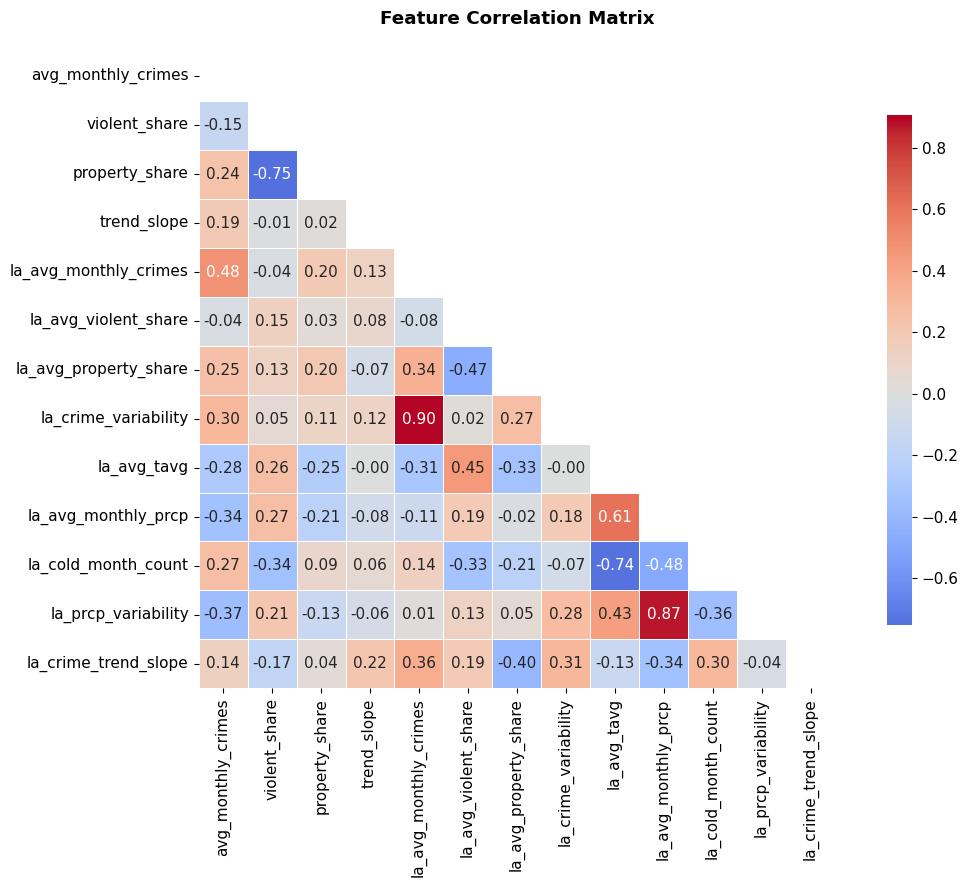

Saved: nb1_correlation_matrix.png


In [41]:
# ── Correlation heatmap of features ──
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_correlation_matrix.png")

## 5. Train/Test Split

We use stratified splitting to maintain class proportions in both sets.  
80/20 split gives ~1,222 training samples and ~305 test samples — sufficient  
for Random Forest with 13 features.

In [42]:
# ── Encode target labels ──
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {list(le.classes_)} → {list(range(len(le.classes_)))}")

# ── Stratified train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
for cls_idx, cls_name in enumerate(le.classes_):
    count = (y_train == cls_idx).sum()
    print(f"  {cls_name}: {count} ({count/len(y_train)*100:.1f}%)")

Classes: ['High Crime', 'Lower Crime', 'Moderate Crime'] → [0, 1, 2]

Training set: 1221 samples
Test set:     306 samples

Training class distribution:
  High Crime: 416 (34.1%)
  Lower Crime: 405 (33.2%)
  Moderate Crime: 400 (32.8%)


## 6. Random Forest Classifier

Random Forest builds an ensemble of decision trees, each trained on a random  
bootstrap sample with a random subset of features. The final prediction is the  
majority vote across all trees. This makes it robust to overfitting and effective  
on tabular data with mixed feature types.

**Hyperparameters chosen:**
- `n_estimators=300`: More trees improve stability without significant cost  
- `max_depth=10`: Prevents overfitting on 1,500 samples  
- `min_samples_leaf=5`: Ensures leaf nodes represent meaningful groups  
- `class_weight='balanced'`: Adjusts for any class imbalance

In [43]:
# ── Train Random Forest ──
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# ── Predictions ──
rf_pred = rf_model.predict(X_test)

# ── Evaluation ──
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("=" * 60)
print("RANDOM FOREST — TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:         {rf_accuracy:.4f} ({rf_accuracy*100:.1f}%)")
print(f"Weighted F1:      {rf_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

RANDOM FOREST — TEST SET RESULTS
Accuracy:         0.9281 (92.8%)
Weighted F1:      0.9281

Classification Report:
                precision    recall  f1-score   support

    High Crime       0.90      0.93      0.92       105
   Lower Crime       0.97      0.96      0.97       101
Moderate Crime       0.92      0.89      0.90       100

      accuracy                           0.93       306
     macro avg       0.93      0.93      0.93       306
  weighted avg       0.93      0.93      0.93       306



In [44]:
# ── Cross-validation for robustness ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X, y_encoded, cv=cv, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"Individual folds: {[f'{s:.4f}' for s in rf_cv_scores]}")

5-Fold Cross-Validation Accuracy: 0.9149 ± 0.0136
Individual folds: ['0.9052', '0.9281', '0.9049', '0.9016', '0.9344']


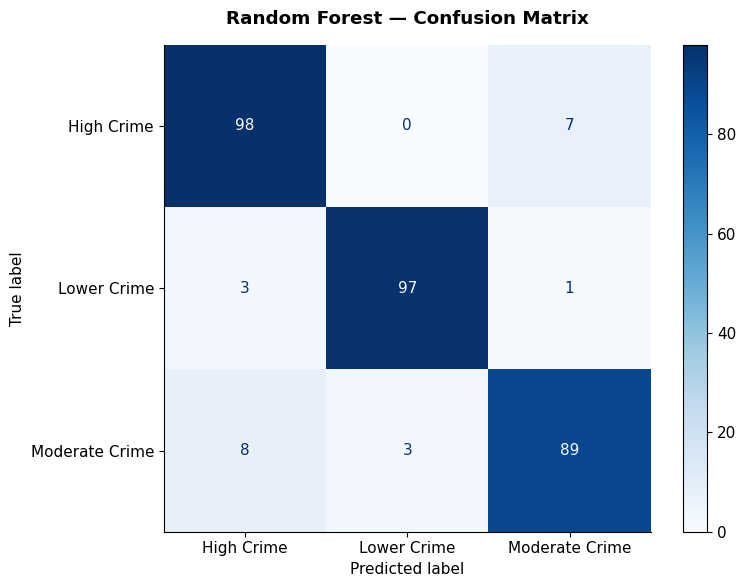

Saved: nb1_rf_confusion_matrix.png


In [45]:
# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_rf_confusion_matrix.png")

## 7. Feature Importance Analysis

Random Forest provides feature importance via Mean Decrease in Impurity (MDI).  
This reveals which features most influence the classification

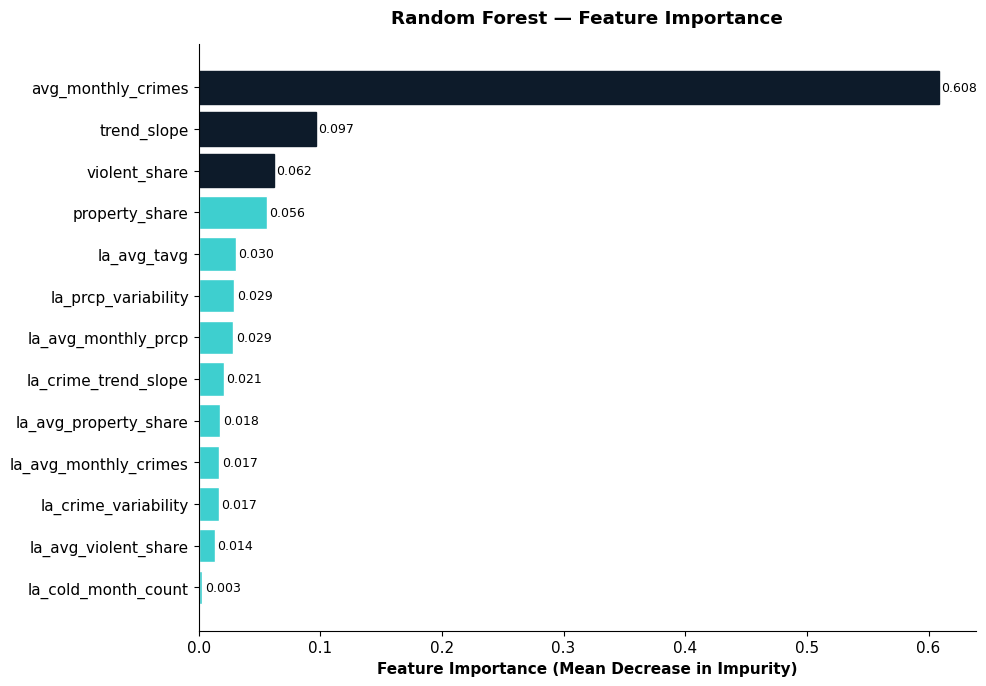

Saved: nb1_rf_feature_importance.png

Top 3 most important features:
  avg_monthly_crimes: 0.6083
  trend_slope: 0.0966
  violent_share: 0.0618


In [46]:
# ── Feature importance bar chart ──
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='#3ecfcf', edgecolor='white')

top3 = feat_imp.nlargest(3, 'importance')['feature'].values
for bar, feat in zip(bars, feat_imp['feature']):
    if feat in top3:
        bar.set_color('#0d1b2a')

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontweight='bold')
ax.set_title('Random Forest — Feature Importance', fontweight='bold', pad=15)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_rf_feature_importance.png")

print(f"\nTop 3 most important features:")
for _, row in feat_imp.nlargest(3, 'importance').iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

## 8. Gradient Boosting Classifier

Gradient Boosting builds trees sequentially — each new tree corrects the errors  
of the previous ensemble. This generally achieves lower bias than Random Forest  
but is more prone to overfitting if not carefully regularised.

**Key difference from Random Forest:**  
- RF: Trees built in parallel, independence reduces variance  
- GB: Trees built sequentially, each correcting predecessor's residuals

In [47]:
# ── Train Gradient Boosting ──
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average='weighted')

print("=" * 60)
print("GRADIENT BOOSTING — TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:         {gb_accuracy:.4f} ({gb_accuracy*100:.1f}%)")
print(f"Weighted F1:      {gb_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=le.classes_))

gb_cv_scores = cross_val_score(gb_model, X, y_encoded, cv=cv, scoring='accuracy')
print(f"5-Fold CV Accuracy: {gb_cv_scores.mean():.4f} ± {gb_cv_scores.std():.4f}")

GRADIENT BOOSTING — TEST SET RESULTS
Accuracy:         0.9673 (96.7%)
Weighted F1:      0.9673

Classification Report:
                precision    recall  f1-score   support

    High Crime       0.95      0.98      0.97       105
   Lower Crime       0.99      0.98      0.99       101
Moderate Crime       0.96      0.94      0.95       100

      accuracy                           0.97       306
     macro avg       0.97      0.97      0.97       306
  weighted avg       0.97      0.97      0.97       306

5-Fold CV Accuracy: 0.9686 ± 0.0105


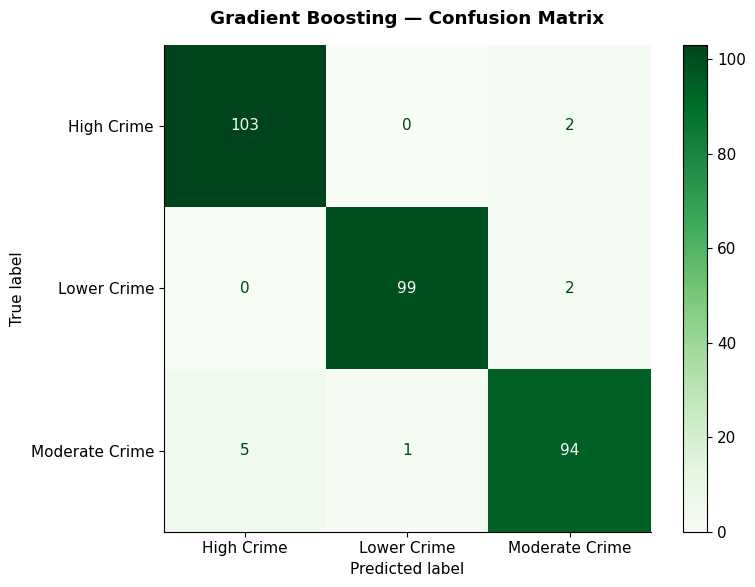

Saved: nb1_gb_confusion_matrix.png


In [48]:
# ── GB Confusion Matrix ──
fig, ax = plt.subplots(figsize=(8, 6))
cm_gb = confusion_matrix(y_test, gb_pred)
disp_gb = ConfusionMatrixDisplay(cm_gb, display_labels=le.classes_)
disp_gb.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Gradient Boosting — Confusion Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_gb_confusion_matrix.png")

## 9. Model Comparison: RF vs GB vs Rule-Based Baseline

The rule-based system classifies using within-LA percentile thresholds.  
We now compare all three approaches to see whether ML adds predictive value  
and whether the models agree with the interpretable baseline.

In [49]:
# ── Side-by-side comparison ──
comparison = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Weighted F1', '5-Fold CV Mean', '5-Fold CV Std'],
    'Random Forest': [
        f'{rf_accuracy:.4f}', f'{rf_f1:.4f}',
        f'{rf_cv_scores.mean():.4f}', f'{rf_cv_scores.std():.4f}'
    ],
    'Gradient Boosting': [
        f'{gb_accuracy:.4f}', f'{gb_f1:.4f}',
        f'{gb_cv_scores.mean():.4f}', f'{gb_cv_scores.std():.4f}'
    ]
})
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))

print(f"\n\nAGREEMENT WITH RULE-BASED BASELINE")
print("=" * 60)
rf_agreement = (rf_pred == y_test).mean()
gb_agreement = (gb_pred == y_test).mean()
print(f"Random Forest agreement:    {rf_agreement:.1%}")
print(f"Gradient Boosting agreement: {gb_agreement:.1%}")
print(f"\nInterpretation: High agreement validates that the rule-based system")
print(f"captures genuine patterns. Per Rudin (2019), when ML and interpretable")
print(f"models achieve similar accuracy, the interpretable model is preferable")
print(f"for high-stakes decision domains.")

MODEL COMPARISON
        Metric Random Forest Gradient Boosting
 Test Accuracy        0.9281            0.9673
   Weighted F1        0.9281            0.9673
5-Fold CV Mean        0.9149            0.9686
 5-Fold CV Std        0.0136            0.0105


AGREEMENT WITH RULE-BASED BASELINE
Random Forest agreement:    92.8%
Gradient Boosting agreement: 96.7%

Interpretation: High agreement validates that the rule-based system
captures genuine patterns. Per Rudin (2019), when ML and interpretable
models achieve similar accuracy, the interpretable model is preferable
for high-stakes decision domains.


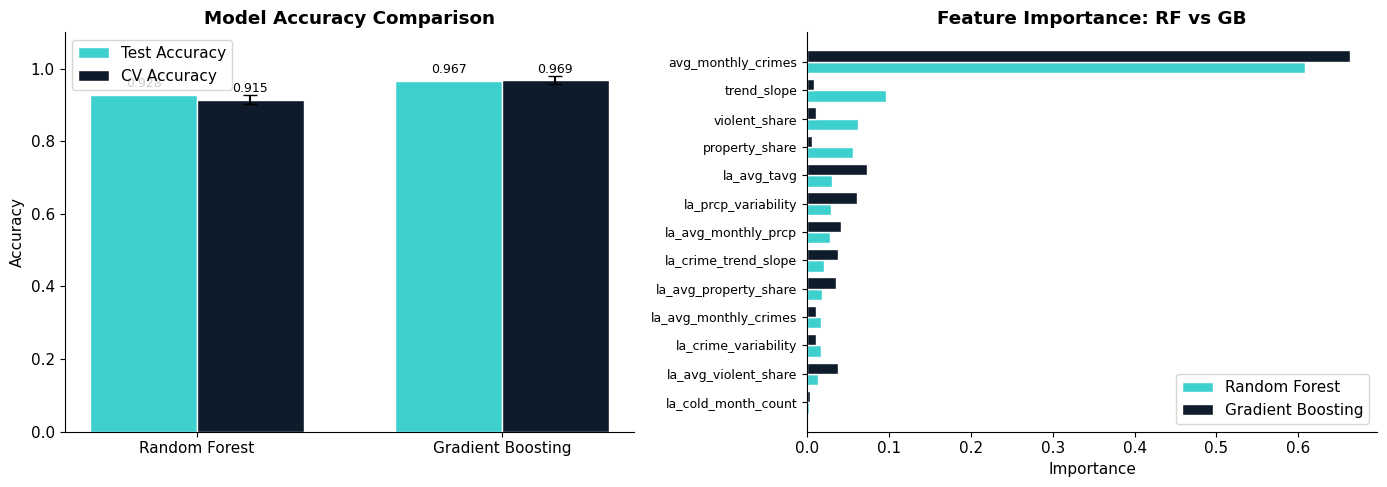

Saved: nb1_model_comparison.png


In [50]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random Forest', 'Gradient Boosting']
test_accs = [rf_accuracy, gb_accuracy]
cv_accs = [rf_cv_scores.mean(), gb_cv_scores.mean()]
cv_stds = [rf_cv_scores.std(), gb_cv_scores.std()]

x = np.arange(len(models))
width = 0.35
bars1 = axes[0].bar(x - width/2, test_accs, width, label='Test Accuracy',
                     color='#3ecfcf', edgecolor='white')
bars2 = axes[0].bar(x + width/2, cv_accs, width, label='CV Accuracy',
                     color='#0d1b2a', edgecolor='white', yerr=cv_stds, capsize=5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

gb_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'RF': rf_model.feature_importances_,
    'GB': gb_model.feature_importances_
}).sort_values('RF', ascending=True)

y_pos = np.arange(len(gb_imp))
axes[1].barh(y_pos - 0.2, gb_imp['RF'], 0.4, label='Random Forest',
             color='#3ecfcf', edgecolor='white')
axes[1].barh(y_pos + 0.2, gb_imp['GB'], 0.4, label='Gradient Boosting',
             color='#0d1b2a', edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(gb_imp['feature'], fontsize=9)
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance: RF vs GB', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb1_model_comparison.png")

## 10. Ablation Study: Classification Without Direct Crime Count

Since `neigh_intensity` is derived from `avg_monthly_crimes`, including it as a  
feature lets the model trivially learn the thresholds. This ablation removes it  
to test whether the remaining features (crime composition, trends, weather,  
area context) carry enough signal to predict crime intensity independently.

it tests whether crime *character*  
(violent share, property share, trend direction) predicts crime *volume class*.

In [51]:
# ── Features without avg_monthly_crimes ──
ABLATION_COLS = [c for c in FEATURE_COLS if c != 'avg_monthly_crimes']
print(f"Ablation features ({len(ABLATION_COLS)}): {ABLATION_COLS}")

X_abl_train = X_train[ABLATION_COLS]
X_abl_test = X_test[ABLATION_COLS]

rf_abl = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_abl.fit(X_abl_train, y_train)
rf_abl_pred = rf_abl.predict(X_abl_test)
rf_abl_acc = accuracy_score(y_test, rf_abl_pred)
rf_abl_f1 = f1_score(y_test, rf_abl_pred, average='weighted')

gb_abl = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    min_samples_leaf=10, subsample=0.8, random_state=42
)
gb_abl.fit(X_abl_train, y_train)
gb_abl_pred = gb_abl.predict(X_abl_test)
gb_abl_acc = accuracy_score(y_test, gb_abl_pred)
gb_abl_f1 = f1_score(y_test, gb_abl_pred, average='weighted')

print("ABLATION STUDY: Without avg_monthly_crimes")
print("=" * 60)
ablation_results = pd.DataFrame({
    'Model': ['RF (all features)', 'RF (no crime count)',
              'GB (all features)', 'GB (no crime count)'],
    'Accuracy': [rf_accuracy, rf_abl_acc, gb_accuracy, gb_abl_acc],
    'Weighted F1': [rf_f1, rf_abl_f1, gb_f1, gb_abl_f1]
})
print(ablation_results.to_string(index=False))

print(f"\nAccuracy drop (RF): {rf_accuracy - rf_abl_acc:.4f}")
print(f"Accuracy drop (GB): {gb_accuracy - gb_abl_acc:.4f}")

Ablation features (12): ['violent_share', 'property_share', 'trend_slope', 'la_avg_monthly_crimes', 'la_avg_violent_share', 'la_avg_property_share', 'la_crime_variability', 'la_avg_tavg', 'la_avg_monthly_prcp', 'la_cold_month_count', 'la_prcp_variability', 'la_crime_trend_slope']
ABLATION STUDY: Without avg_monthly_crimes
              Model  Accuracy  Weighted F1
  RF (all features)  0.928105     0.928125
RF (no crime count)  0.500000     0.495106
  GB (all features)  0.967320     0.967292
GB (no crime count)  0.650327     0.649627

Accuracy drop (RF): 0.4281
Accuracy drop (GB): 0.3170


## 11. Save Results

In [52]:
# ── Add ML predictions to the full dataset ──
df_out = df.copy()

df_out['rf_predicted_class'] = le.inverse_transform(rf_model.predict(df_out[FEATURE_COLS]))
df_out['gb_predicted_class'] = le.inverse_transform(gb_model.predict(df_out[FEATURE_COLS]))

df_out['rf_agrees_rule'] = df_out['rf_predicted_class'] == df_out['neigh_intensity']
df_out['gb_agrees_rule'] = df_out['gb_predicted_class'] == df_out['neigh_intensity']

# Save enriched neighbourhood file
out_path = PROCESSED_DIR / 'neighbourhood_ml_classified.parquet'
df_out.to_parquet(out_path, index=False)
print(f"Saved: {out_path.name}")
print(f"  {len(df_out)} neighbourhoods with ML predictions")
print(f"  RF agreement: {df_out['rf_agrees_rule'].mean():.1%}")
print(f"  GB agreement: {df_out['gb_agrees_rule'].mean():.1%}")

# ── Save comparison summary ──
summary_path = PROCESSED_DIR / 'ml_model_comparison.csv'
comparison_full = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'RF (ablation)', 'GB (ablation)'],
    'Test_Accuracy': [rf_accuracy, gb_accuracy, rf_abl_acc, gb_abl_acc],
    'Weighted_F1': [rf_f1, gb_f1, rf_abl_f1, gb_abl_f1],
    'CV_Mean': [rf_cv_scores.mean(), gb_cv_scores.mean(), np.nan, np.nan],
    'CV_Std': [rf_cv_scores.std(), gb_cv_scores.std(), np.nan, np.nan],
    'Features_Used': ['All 13', 'All 13', '12 (no crime count)', '12 (no crime count)']
})
comparison_full.to_csv(summary_path, index=False)
print(f"Saved: {summary_path.name}")

Saved: neighbourhood_ml_classified.parquet
  1527 neighbourhoods with ML predictions
  RF agreement: 97.4%
  GB agreement: 99.3%
Saved: ml_model_comparison.csv


## 12. Export for Flask Web Application

These CSV files are read by `app.py → _load_insights_ml_vars()` and displayed  
automatically on the Insights page. The enriched parquet file adds ML prediction  
badges to the Area Profile page.

In [53]:
# ═══════════════════════════════════════════════════════════════════════
# 12a. rf_feature_importance.csv  — drives the Feature Importance chart
# ═══════════════════════════════════════════════════════════════════════
fi_export = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_model.feature_importances_,
    'importance_pct': (rf_model.feature_importances_ * 100).round(2)
}).sort_values('importance_pct', ascending=False)

fi_export.to_csv(PROCESSED_DIR / 'rf_feature_importance.csv', index=False)
print("Saved: rf_feature_importance.csv")
print(fi_export.to_string(index=False))

Saved: rf_feature_importance.csv
              feature  importance  importance_pct
   avg_monthly_crimes    0.608277           60.83
          trend_slope    0.096637            9.66
        violent_share    0.061812            6.18
       property_share    0.056046            5.60
          la_avg_tavg    0.030346            3.03
  la_prcp_variability    0.029451            2.95
  la_avg_monthly_prcp    0.028506            2.85
 la_crime_trend_slope    0.020873            2.09
la_avg_property_share    0.017775            1.78
la_avg_monthly_crimes    0.017008            1.70
 la_crime_variability    0.016670            1.67
 la_avg_violent_share    0.013640            1.36
  la_cold_month_count    0.002959            0.30


In [ ]:
# 12b. rf_fold_scores.csv  — drives the CV fold accuracy bar chart
fold_export = pd.DataFrame({
    'fold': [f'Fold {i+1}' for i in range(len(rf_cv_scores))],
    'accuracy': rf_cv_scores.round(6)
})

fold_export.to_csv(PROCESSED_DIR / 'rf_fold_scores.csv', index=False)
print("Saved: rf_fold_scores.csv")
print(fold_export.to_string(index=False))

print(f"\nMean CV accuracy: {rf_cv_scores.mean()*100:.1f}%")
print(f"This value will appear in the accuracy badge on the Insights page.")

Saved: rf_fold_scores.csv
  fold  accuracy
Fold 1  0.905229
Fold 2  0.928105
Fold 3  0.904918
Fold 4  0.901639
Fold 5  0.934426

Mean CV accuracy: 91.5%
This value will appear in the accuracy badge on the Insights page.


In [ ]:
# 12c. Verify all output files exist
expected_files = [
    'neighbourhood_ml_classified.parquet',
    'ml_model_comparison.csv',
    'rf_feature_importance.csv',
    'rf_fold_scores.csv',
]

print("Output file check:")
for fname in expected_files:
    path = PROCESSED_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

print(f"\n{'='*60}")
print("INTEGRATION COMPLETE")
print(f"{'='*60}")
print("The Insights page will now show:")
print("  • Feature importance horizontal bar chart")
print("  • 5-fold CV accuracy bars with mean line")
print("  • Accuracy badge showing CV mean")
print("\nThe Area Profile page will now show:")
print("  • RF/GB predicted class badges in neighbourhood spotlight")
print("  (requires updated area.html — see integration instructions)")

Output file check:
  [OK] neighbourhood_ml_classified.parquet
  [OK] ml_model_comparison.csv
  [OK] rf_feature_importance.csv
  [OK] rf_fold_scores.csv

INTEGRATION COMPLETE
The Insights page will now show:
  • Feature importance horizontal bar chart
  • 5-fold CV accuracy bars with mean line
  • Accuracy badge showing CV mean

The Area Profile page will now show:
  • RF/GB predicted class badges in neighbourhood spotlight
  (requires updated area.html — see integration instructions)
